In [1]:
import pyspark.sql.functions as F
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, HashingTF, MinHashLSH

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
cat_sample_path = "gs://msca-bdp-students-bucket/kireetij_final/df_cat_sample"

df_cat_sample = spark.read.parquet(cat_sample_path)

print("Loaded df_cat_sample rows:", df_cat_sample.count())
df_cat_sample.printSchema()
df_cat_sample.show(5, truncate=80)

Loaded df_cat_sample rows: 564
root
 |-- parent_asin: string (nullable = true)
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- review_ts: timestamp (nullable = true)
 |-- review_date: date (nullable = true)
 |-- main_category: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- price_num: double (nullable = true)
 |-- review_id: long (nullable = true)



+-----------+----------+------------+------+--------------------------------------------------------------------------------+-------------+--------------------------------------------------------------------------------+----------------------------+-----------------+-----------------------+-----------+-------------+--------------------------------------------------------------------------------+---------+------------+
|parent_asin|      asin|helpful_vote|rating|                                                                            text|    timestamp|                                                                           title|                     user_id|verified_purchase|              review_ts|review_date|main_category|                                                                   product_title|price_num|   review_id|
+-----------+----------+------------+------+--------------------------------------------------------------------------------+-------------+-----------------

In [3]:
from pyspark.sql import functions as F

df_time = df_cat_sample.filter(F.col("review_date").isNotNull())

df_old = df_time.filter(F.year("review_date") < 2022)
df_recent = df_time.filter((F.year("review_date") >= 2022) & (F.year("review_date") <= 2023))

print("Old reviews:", df_old.count())
print("Recent (2022–23) reviews:", df_recent.count())

TARGET_PER_PERIOD = 8000  # smaller to be safe

def downsample(df, target):
    c = df.count()
    if c <= target:
        return df
    frac = target / float(c)
    return df.sample(False, frac, seed=42)

df_old_sample    = downsample(df_old, TARGET_PER_PERIOD)
df_recent_sample = downsample(df_recent, TARGET_PER_PERIOD)

print("Old sample:", df_old_sample.count())
print("Recent sample:", df_recent_sample.count())

Old reviews: 522


Recent (2022–23) reviews: 42


Old sample: 522


Recent sample: 42


In [4]:
TEXT_DISTANCE_THRESHOLD = 0.2

def compute_text_dup_stats_for_subset(df_subset, label):
    df_texts = df_subset.select(
        "review_id",
        F.col("text").alias("raw_text")
    ).filter(F.col("raw_text").isNotNull())

    df_texts = (
        df_texts
        .withColumn("raw_text", F.lower(F.col("raw_text")))
        .filter(F.length("raw_text") > 20)
    )

    print(f"[{label}] usable texts:", df_texts.count())

    regex_tok = RegexTokenizer(
        inputCol="raw_text",
        outputCol="tokens",
        pattern="\\W+"
    )

    remover = StopWordsRemover(
        inputCol="tokens",
        outputCol="filtered_tokens"
    )

    hashing_tf = HashingTF(
        inputCol="filtered_tokens",
        outputCol="features",
        numFeatures=2**18,
        binary=True
    )

    minhash = MinHashLSH(
        inputCol="features",
        outputCol="hashes",
        numHashTables=40
    )

    tok  = regex_tok.transform(df_texts)
    tok  = remover.transform(tok)
    feat = hashing_tf.transform(tok)

    mh_model = minhash.fit(feat)
    hashed   = mh_model.transform(feat)

    hashed = (
        hashed
        .filter(F.size("filtered_tokens") > 0)
        .filter(F.col("features").isNotNull())
    ).cache()

    print(f"[{label}] in LSH set:", hashed.count())

    pairs = mh_model.approxSimilarityJoin(
        hashed,
        hashed,
        TEXT_DISTANCE_THRESHOLD,
        distCol="JaccardDistance"
    ).filter(F.col("datasetA.review_id") < F.col("datasetB.review_id"))

    pair_count = pairs.count()
    print(f"[{label}] near-duplicate pairs:", pair_count)

    dup_counts = (
        pairs
        .select(F.col("datasetA.review_id").alias("review_id"))
        .union(pairs.select(F.col("datasetB.review_id").alias("review_id")))
        .groupBy("review_id")
        .count()
        .withColumnRenamed("count", "num_text_dups")
    )

    stats = (
        hashed.select("review_id")
        .join(dup_counts, on="review_id", how="left")
        .fillna({"num_text_dups": 0})
    )

    total = stats.count()
    with_dups = stats.filter(F.col("num_text_dups") > 0).count()
    avg_dups_given_dup = stats.filter(F.col("num_text_dups") > 0).agg(
        F.avg("num_text_dups")
    ).first()[0] or 0.0

    return {
        "label": label,
        "n_reviews": total,
        "n_with_dups": with_dups,
        "frac_with_dups": with_dups/total if total > 0 else 0.0,
        "avg_dups_given_dup": float(avg_dups_given_dup)
    }

In [5]:
stats_old    = compute_text_dup_stats_for_subset(df_old_sample,    "pre-2022")
stats_recent = compute_text_dup_stats_for_subset(df_recent_sample, "2022–2023")

comparison_pdf = pd.DataFrame([stats_old, stats_recent])
comparison_pdf

[pre-2022] usable texts: 522


[pre-2022] in LSH set: 521


[pre-2022] near-duplicate pairs: 3


[2022–2023] usable texts: 42


[2022–2023] in LSH set: 42
[2022–2023] near-duplicate pairs: 0


,label,n_reviews,n_with_dups,frac_with_dups,avg_dups_given_dup
0,pre-2022,521,3,0.005758,2.0
1,2022–2023,42,0,0.000000,0.0


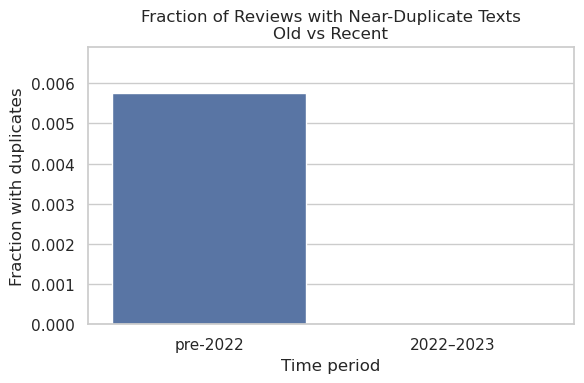

In [6]:
%matplotlib inline

plt.figure(figsize=(6,4))
sns.barplot(data=comparison_pdf, x="label", y="frac_with_dups")
plt.title("Fraction of Reviews with Near-Duplicate Texts\nOld vs Recent")
plt.xlabel("Time period")
plt.ylabel("Fraction with duplicates")
plt.ylim(0, comparison_pdf["frac_with_dups"].max() * 1.2)
plt.tight_layout()
plt.show()

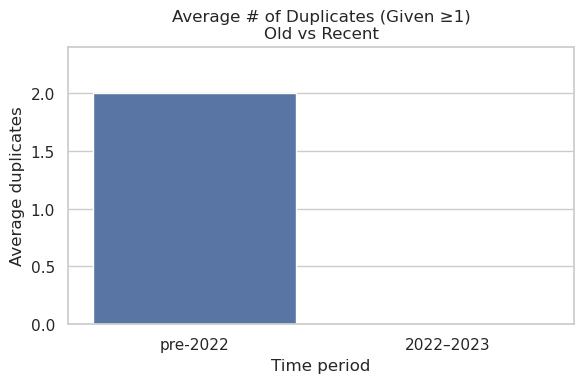

In [7]:
%matplotlib inline

plt.figure(figsize=(6,4))
sns.barplot(data=comparison_pdf, x="label", y="avg_dups_given_dup")
plt.title("Average # of Duplicates (Given ≥1)\nOld vs Recent")
plt.xlabel("Time period")
plt.ylabel("Average duplicates")
plt.ylim(0, comparison_pdf["avg_dups_given_dup"].max() * 1.2)
plt.tight_layout()
plt.show()